In [1]:
%matplotlib inline
# !pip install deeptrack deeplay # Uncomment if running in colab/kaggle

<!--<badge>--><a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231G_LodeSTAR_track_plankton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In [ ]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Define helper functions

In [11]:
def normalize_min_max(img, squeeze_in_2D=False):
    """Normalizes intensities."""
    if squeeze_in_2D:
        img = np.squeeze(img)
    max_intensity = np.max(img)
    min_intensity = np.min(img)
    if max_intensity == min_intensity:
        raise ValueError("Cannot normalize array with uniform intensity.")
    normalized_img = (img - min_intensity) / (
        max_intensity - min_intensity)
    return normalized_img

## 2. Load data

(150, 150)


(-0.5, 149.5, 149.5, -0.5)

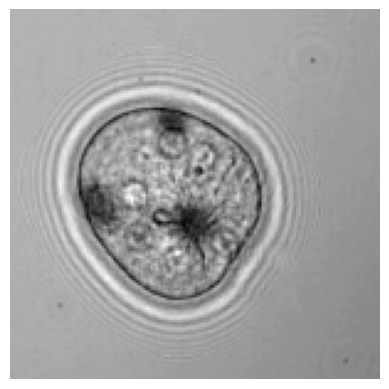

In [ ]:
plankton_data = normalize_min_max(np.load("./assets/plankton.npy"))

t, x, y, w = (0, 450, 320, 150) 
crop = plankton_data[t, y:y+w, x:x+w, 0]
print(crop.shape)
plt.imshow(crop, cmap="gray")
plt.axis("off")

## 3. Train Model

INFO: 
  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | model         | ConvolutionalNeuralNetwork | 251 K  | train
1 | between_loss  | L1Loss                     | 0      | train
2 | within_loss   | L1Loss                     | 0      | train
3 | train_metrics | MetricCollection           | 0      | train
4 | val_metrics   | MetricCollection           | 0      | train
5 | test_metrics  | MetricCollection           | 0      | train
6 | optimizer     | Adam                       | 0      | train
---------------------------------------------------------------------
251 K     Trainable params
0         Non-trainable params
251 K     Total params
1.004     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                       | Params | Mode 
------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

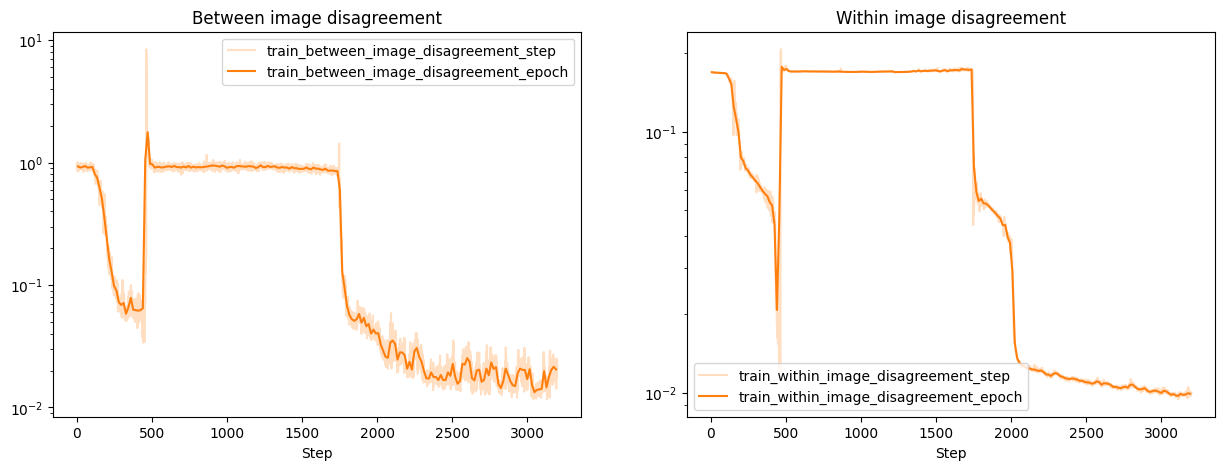

In [ ]:
# Add empty batch dimension for compatability.
training_crop = crop[np.newaxis]

model = dl.LodeSTAR(n_transforms=8, optimizer=dl.Adam(lr=1e-3)).build()

training_pipeline = (
    dt.Value(training_crop)
    >> dt.AveragePooling(ksize=(3, 3, 2))
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)

train_dataset = dt.pytorch.Dataset(
     training_pipeline,
     length=256,
     replace=False,
)
dataloader = dl.DataLoader(
     train_dataset,
     batch_size=16,
     shuffle=True,
)

# Start training.
trainer_lodestar = dl.Trainer(max_epochs=200, accelerator="auto")
trainer_lodestar.fit(model, dataloader)

# Plot history and save weights.
trainer_lodestar.history.plot()
torch.save(model.state_dict(), "lodestar_weights_plankton.pth")

## Test Model

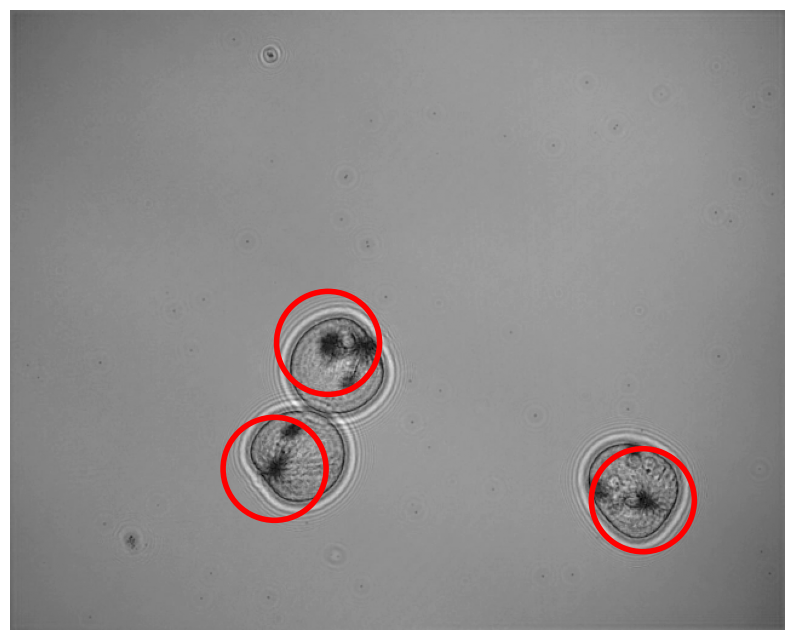

In [140]:
# May need to tune these to get optimal performance!
alpha = 0.5
cutoff = 0.9998

# Last frame of the movie.
frame_index = 1
exeperimental_image = plankton_data[frame_index:frame_index+1,:, :, 0]

# Convert to tensor for LodeSTAR.
image = torch.as_tensor(
    exeperimental_image,
    dtype=torch.float32
).detach().to("cpu").unsqueeze(0)

detections = model.detect(image, alpha=alpha, beta=1-alpha, cutoff=cutoff, mode="quantile")[0]
plt.figure(figsize=(10, 10))
plt.imshow(plankton_data[frame_index], cmap="gray")
plt.axis("off")
plt.scatter(detections[:, 1], detections[:, 0], s=5500, linewidths=4, facecolors="none", edgecolors="r")